# Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from collections import Counter

sns.set_style('darkgrid')
pd.set_option('display.max_columns', None)

# Load Data

In [4]:
df = pd.read_csv('cleaned_discrete_maths_exams.csv')
print(df.shape)
df.head(2)

(168, 18)


,paper,page,method,length,page_count,text,exam_date,semester_info,year,sitting,doc_type,text_clean,question,letter,roman,marks,total,topics
0,Discrete_Mathematics_2013_Final_E.pdf,1,text,740,12,1 WIT BACHELOR OF SCIENCE ...,DECEMBER,SEMESTER 1 - YEAR 1,2013,Final,Exam,1 wit bachelor of science (hons) in - applied ...,False,False,False,False,False,[]
1,Discrete_Mathematics_2013_Final_E.pdf,2,text,924,12,2 Question 1 (a) The universal set ...,DECEMBER,SEMESTER 1 - YEAR 1,2013,Final,Exam,"2 question 1 (a) the universal set is {1, 2, 3...",True,True,True,True,False,"['Propositional Logic', 'Relations']"


# Data Types & Missing Values

In [5]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

paper            object
page              int64
method           object
length            int64
page_count        int64
text             object
exam_date        object
semester_info    object
year              int64
sitting          object
doc_type         object
text_clean       object
question           bool
letter             bool
roman              bool
marks              bool
total              bool
topics           object
dtype: object

Missing values:
paper            0
page             0
method           0
length           0
page_count       0
text             0
exam_date        0
semester_info    0
year             0
sitting          0
doc_type         0
text_clean       0
question         0
letter           0
roman            0
marks            0
total            0
topics           0
dtype: int64


#  Numeric Summary

In [6]:
df[['length', 'page_count']].describe()

,length,page_count
count,168.000000,168.000000
mean,828.172619,11.297619
std,336.003956,4.498249
min,114.000000,6.000000
25%,555.500000,8.000000
50%,785.500000,10.000000
75%,1044.750000,14.000000
max,1875.000000,21.000000


# Categorical Distributions

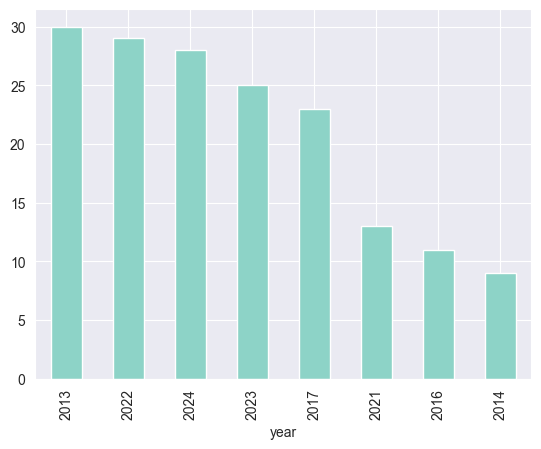

In [7]:
df['year'].value_counts().plot(kind='bar')
plt.show()

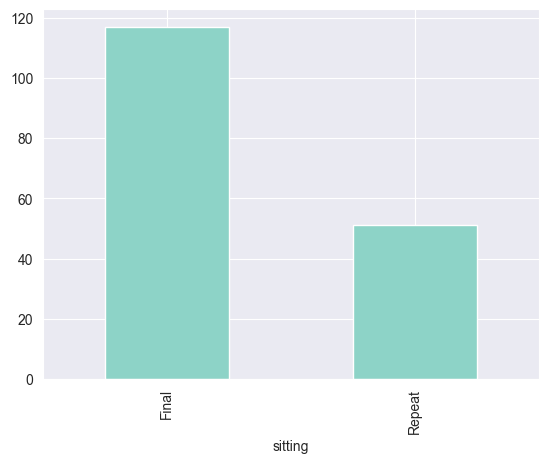

In [8]:
df['sitting'].value_counts().plot(kind='bar')
plt.show()

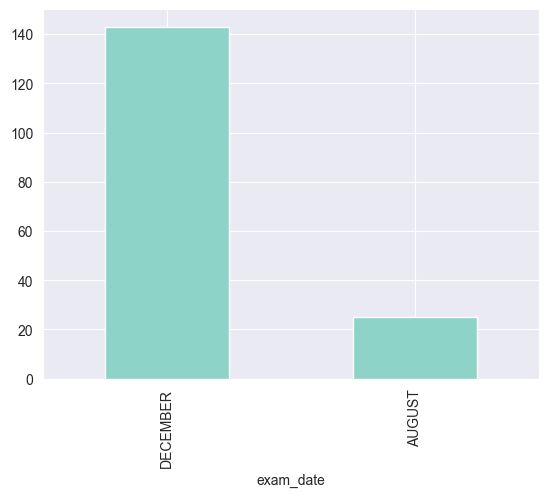

In [9]:
df['exam_date'].value_counts().plot(kind='bar')
plt.show()

## Boolean Flags

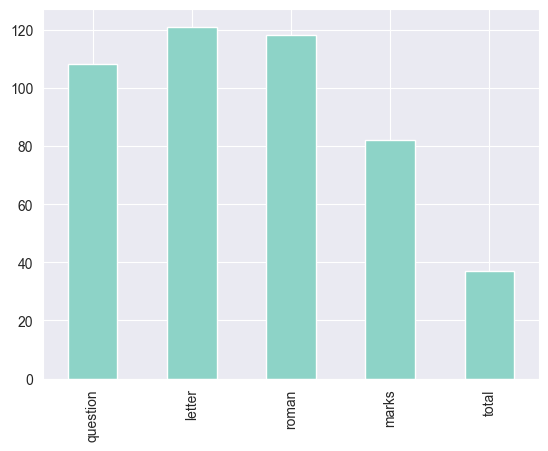

In [10]:
df[['question', 'letter', 'roman', 'marks', 'total']].sum().plot(kind='bar')
plt.show()

In [11]:
df[['question', 'letter', 'roman', 'marks', 'total']].mean() * 100

question    64.285714
letter      72.023810
roman       70.238095
marks       48.809524
total       22.023810
dtype: float64

# Text Length & Page Count Distributions

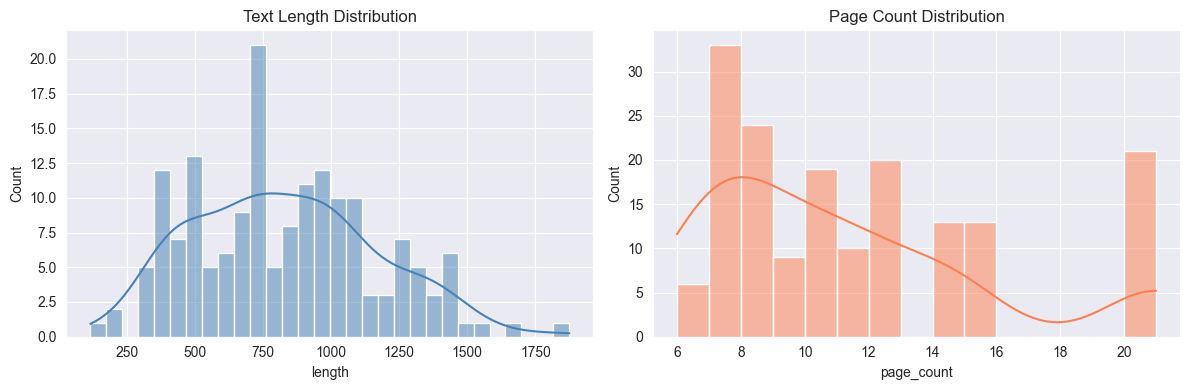

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['length'], bins=30, ax=axes[0], kde=True, color='steelblue')
axes[0].set_title('Text Length Distribution')

sns.histplot(df['page_count'], bins=15, ax=axes[1], kde=True, color='coral')
axes[1].set_title('Page Count Distribution')

plt.tight_layout()
plt.show()

# Pages Per Year by Sitting

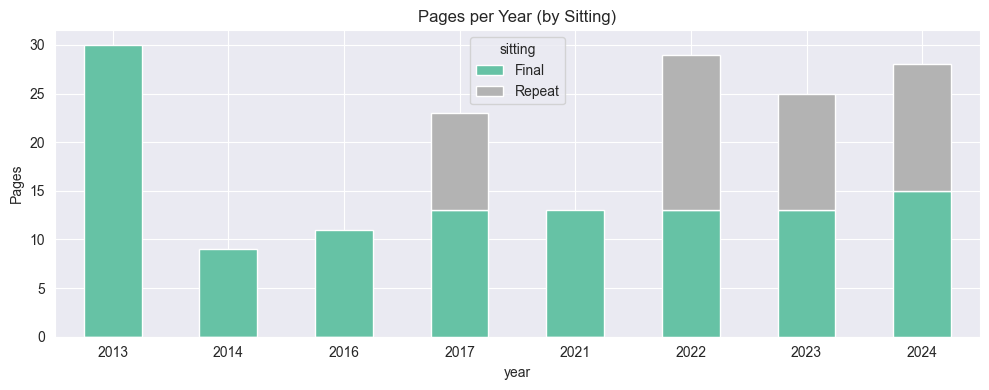

In [13]:
year_sit = df.groupby(['year', 'sitting']).size().unstack(fill_value=0)
year_sit.plot(kind='bar', stacked=True, figsize=(10, 4), colormap='Set2')
plt.title('Pages per Year (by Sitting)')
plt.ylabel('Pages')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Topic Frequency

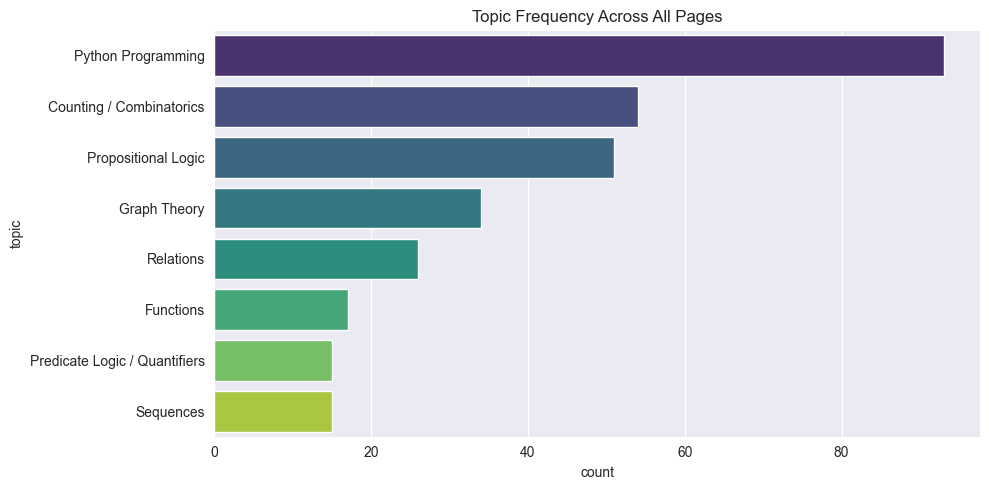

In [14]:
all_topics = []
for val in df['topics']:
    try:
        all_topics.extend(ast.literal_eval(val))
    except:
        pass

topic_counts = Counter(all_topics)
topic_df = pd.DataFrame(topic_counts.most_common(), columns=['topic', 'count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=topic_df, x='count', y='topic', palette='viridis', hue='topic', legend=False)
plt.title('Topic Frequency Across All Pages')
plt.tight_layout()
plt.show()

# Topics Over Time

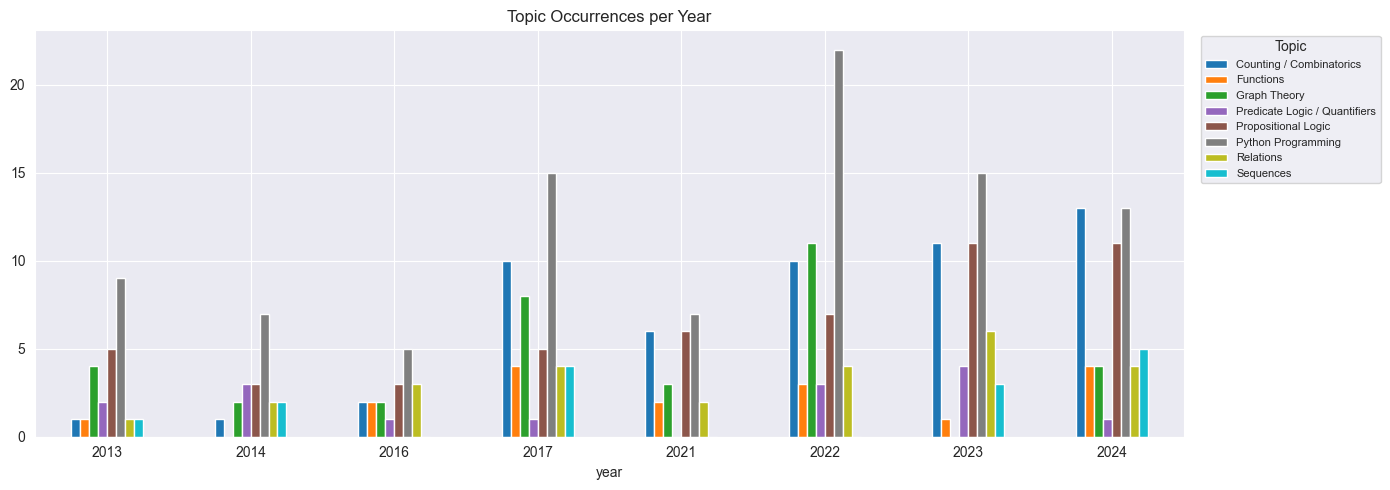

In [15]:
rows = []
for _, row in df.iterrows():
    try:
        topics = ast.literal_eval(row['topics'])
    except:
        topics = []
    for t in topics:
        rows.append({'year': row['year'], 'topic': t})

topic_year_df = pd.DataFrame(rows)
pivot = topic_year_df.groupby(['year', 'topic']).size().unstack(fill_value=0)
pivot.plot(kind='bar', figsize=(14, 5), colormap='tab10')
plt.title('Topic Occurrences per Year')
plt.xticks(rotation=0)
plt.legend(title='Topic', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Box Plots

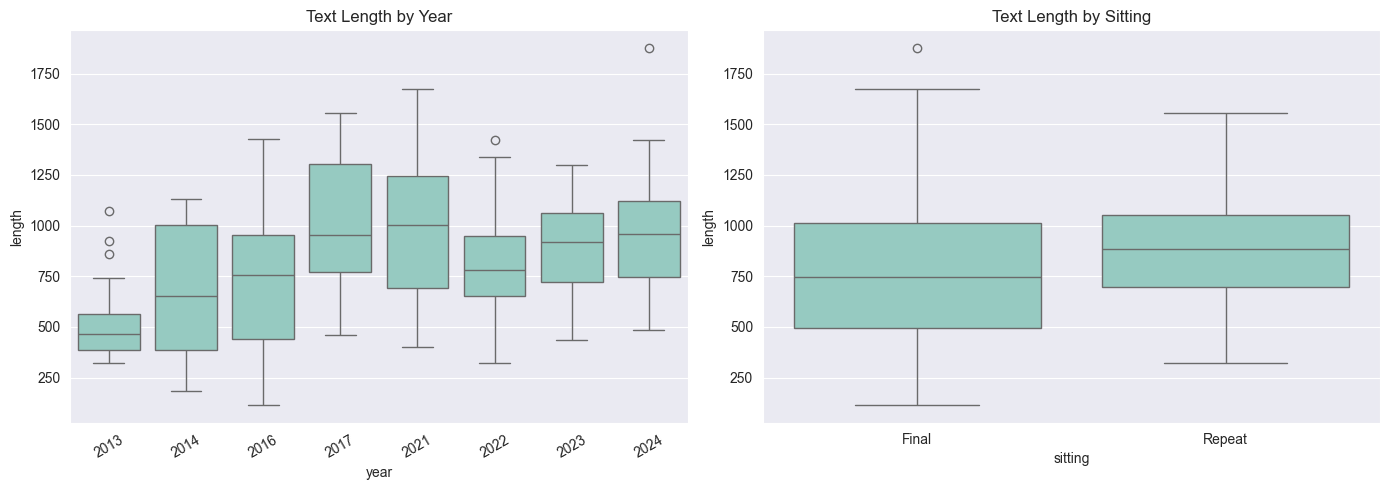

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='year', y='length', ax=axes[0])
axes[0].set_title('Text Length by Year')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df, x='sitting', y='length', ax=axes[1])
axes[1].set_title('Text Length by Sitting')

plt.tight_layout()
plt.show()

# Correlation Heatmap

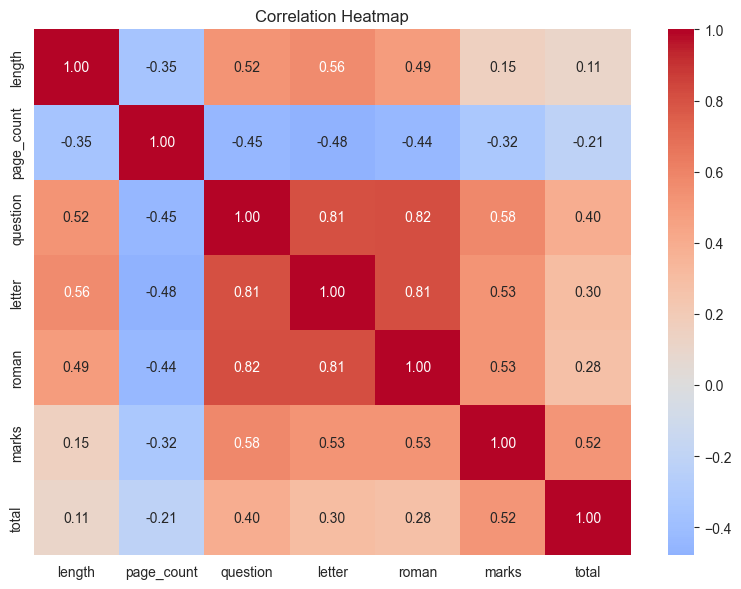

In [17]:
corr_cols = ['length', 'page_count', 'question', 'letter', 'roman', 'marks', 'total']
corr_df = df[corr_cols].astype(float)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

# Summary Stats

In [18]:
print('=== Dataset Summary ===')
print(f'Total rows       : {len(df)}')
print(f'Unique papers    : {df["paper"].nunique()}')
print(f'Year range       : {df["year"].min()} – {df["year"].max()}')
print(f'Sittings         : {dict(df["sitting"].value_counts())}')
print(f'No. of topics    : {len(topic_counts)}')
print(f'Most common topic: {topic_counts.most_common(1)[0]}')
print(f'Avg text length  : {df["length"].mean():.0f} chars')
print(f'Pages with marks : {df["marks"].sum()} ({df["marks"].mean()*100:.1f}%)')

=== Dataset Summary ===
Total rows       : 168
Unique papers    : 19
Year range       : 2013 – 2024
Sittings         : {'Final': np.int64(117), 'Repeat': np.int64(51)}
No. of topics    : 8
Most common topic: ('Python Programming', 93)
Avg text length  : 828 chars
Pages with marks : 82 (48.8%)
